#Tech Challenge: Case NPS Preditivo

##1: Entendimento do Negócio

* **Contexto do projeto:**

  Com o crescimento nacional do e-commerce, a empresa começou a lidar com um número muito alto de pedidos, entregas e interações. Isso acarretou um desafio relevante na experiência do cliente, que foi refletido na alta variabilidade de notas do NPS (Net Promoter Score); mesmo com indicadores operacionais aparentemente semelhantes, alguns clientes se tornam promotores da marca, enquanto outros viram detratores.
  <br><br>

* **Pergunta Norteadora**

  *"Quais fatores operacionais realmente influenciam a satisfação do cliente e como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS?"*
  <br>

* **Qual problema de negócio está sendo resolvido?**

  O principal problema é a alta insatisfação dos clientes e o número de detratores no e-commerce. O objetivo é entender quais problemas operacionais, como falhas na logística e no atendimento, estão prejudicando a experiência do cliente e, assim, deixar de agir só depois dos problemas para começar a preveni-los.
 <br>

* **Por que o NPS é importante para um e-commerce?**

  O *Net Promoter Score* (NPS) é o principal termômetro de lealdade e retenção do cliente. A rentabilidade do negócio depende diretamente de uma base saudável de clientes satisfeitos que gerem recompra orgânica.
<br>

* **Quais áreas poderiam se beneficiar desses insights?**

  * **Logística:** Para reavaliar prazos, rotas críticas e o desempenho das transportadoras parceiras.
  * **Atendimento (SAC):** Para otimizar o tempo de resolução de chamados e reduzir o esforço do cliente.
  * **Produto e Comercial:** Para alinhar a promessa de venda à experiência real entregue.
  * **Diretoria / Gestão Estratégica:** Para priorização de investimentos e mitigação de riscos de *churn*.
<br>

### Reflexão sobre o Impacto do NPS

* **Recompra:** Clientes detratores (notas baixas) possuem taxa de recompra próxima de zero, enquanto promotores sustentam a saúde da empresa com compras recorrentes.
* **Boca a boca:** No ambiente digital do e-commerce, insatisfações geram avaliações negativas públicas e perda de reputação de marca.
* **Market share:** Uma alta concentração de detratores drena recursos operacionais com o pós-venda e empurra o consumidor para a concorrência, prejudicando a participação de mercado.

### Indicadores de Mercado Complementares
* **Benchmarks de NPS do setor:** Para entender se a nota média da empresa está alinhada ou abaixo da média do varejo digital.
* **SLA Logístico:** Percentual de entregas realizadas dentro do prazo prometido.



## 2. Definição da Target (Variável Resposta)

* **Qual variável representa a satisfação do cliente?**
  A variável alvo é a `nps_score` (Nota do Net Promoter Score).

* **Por que ela foi escolhida?**
  Porque resume em uma única métrica a chance de o cliente recomendar a marca, sendo um bom indicador de lealdade e da qualidade da experiência que ele teve do início ao fim.

* **Em que momento da jornada essa informação é coletada?**
  A pesquisa é enviada depois da venda, quando o pedido já foi entregue e o cliente já teve qualquer contato necessário com o suporte. Assim, conseguimos avaliar a experiência completa de compra.

* **Existe algum risco de usar essa variável de forma inadequada?**
  Sim. Um erro seria olhar o NPS apenas como uma métrica isolada, sem entender as causas dos problemas operacionais. Também é importante considerar o momento em que a pesquisa é feita, pois um problema pontual ainda não resolvido pode influenciar negativamente a resposta do cliente.

Importar as bibliotecas Python

In [78]:
#Caso não tenha as bibliotecas instaladas:
# !pip install pandas numpy matplotlib seaborn plotly

#importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Bibliotecas importadas")

Bibliotecas importadas


Carregar a Base de Dados

In [79]:
#carregar o arquivo da base de dados:

file_path = 'data/desafio_nps_fase_1.csv'

df = pd.read_csv(file_path)
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Qualidade dos dados

In [80]:
#estrutura do dataset
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [81]:
#Dados 'missing' e duplicados:
df.isnull().sum()
df.duplicated().sum()

print(f"Total de nulos: {df.isnull().sum().sum()}") #imprime o resultado
print(f"Total de registros duplicados: {df.duplicated().sum()}")

Total de nulos: 0
Total de registros duplicados: 0


In [82]:
#Visão Geral do Dataframe
display(df.describe())

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


Visualização Gráfica dos Dados

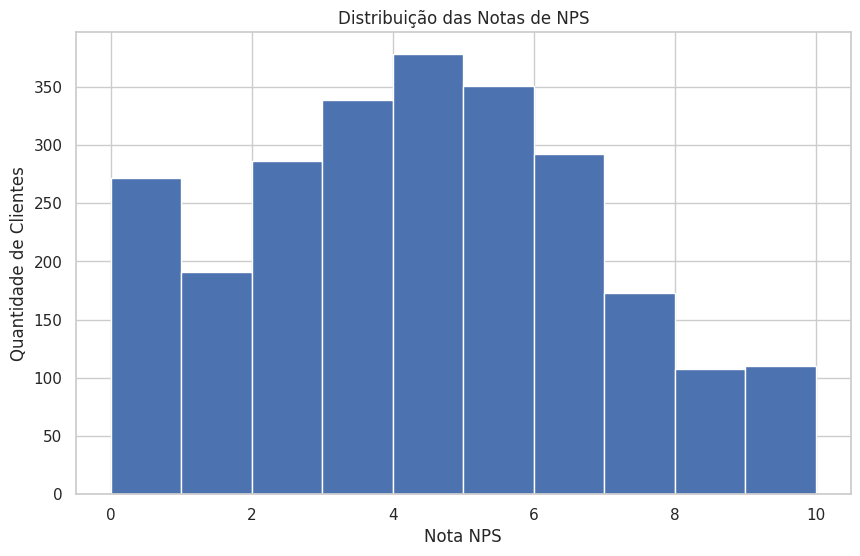

In [83]:
#histograma de distribuição da quantiidade de clientes x nota nps
df['nps_score'].hist(bins=10)

plt.title('Distribuição das Notas de NPS')
plt.xlabel('Nota NPS')
plt.ylabel('Quantidade de Clientes') # Ajustado para refletir exatamente o volume de pessoas

plt.show()

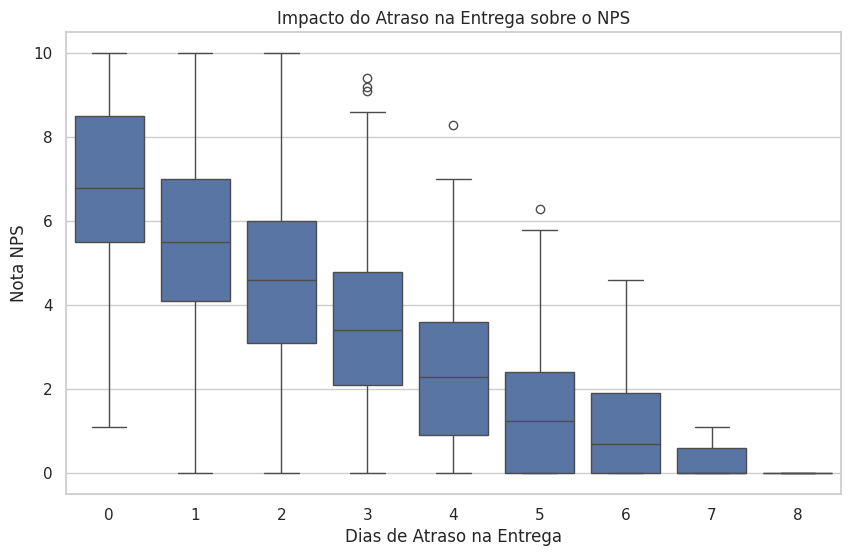

In [84]:
#boxplot atraso x nota
sns.boxplot(data=df, x='delivery_delay_days', y='nps_score')

plt.title('Impacto do Atraso na Entrega sobre o NPS')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('Nota NPS')

plt.show()

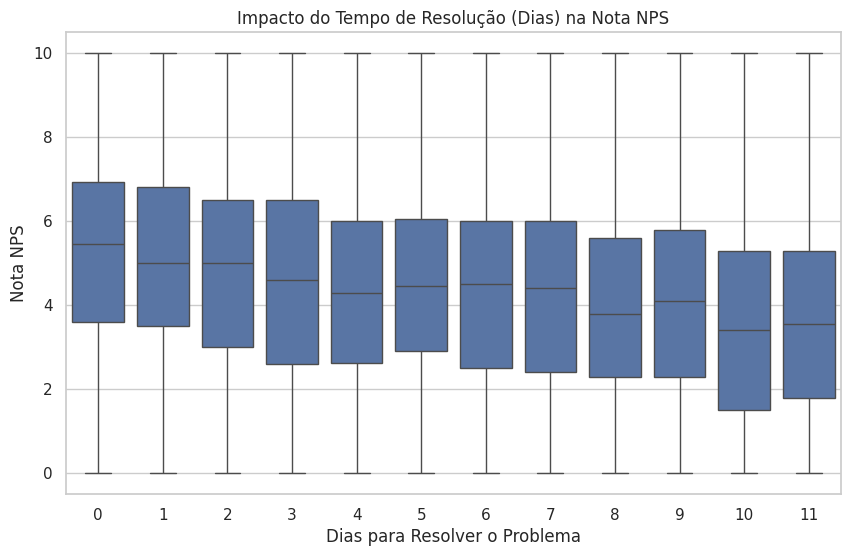

In [85]:
#nro de contatos x nota
sns.boxplot(data=df, x='resolution_time_days', y='nps_score')
plt.title('Impacto do Tempo de Resolução (Dias) na Nota NPS')
plt.xlabel('Dias para Resolver o Problema')
plt.ylabel('Nota NPS')
plt.show()

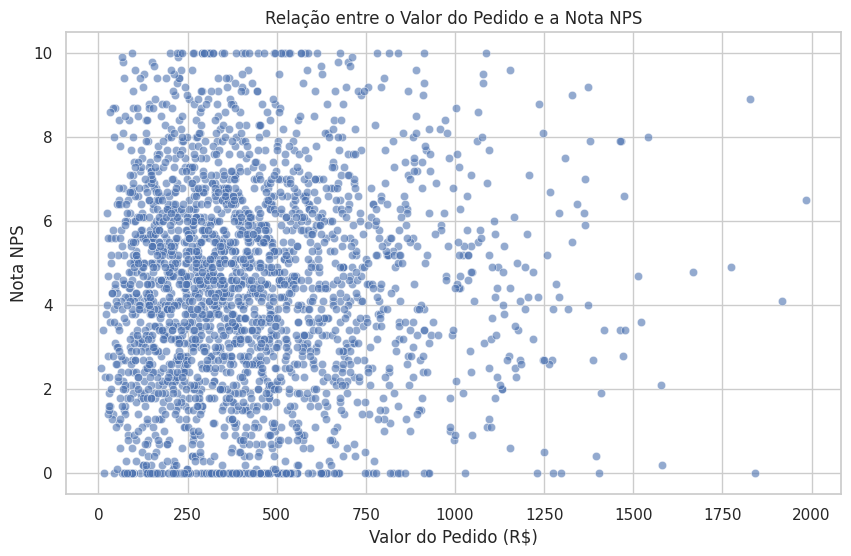

In [86]:
#valor do pedido x nota
sns.scatterplot(data=df, x='order_value', y='nps_score', alpha=0.6)
plt.title('Relação entre o Valor do Pedido e a Nota NPS')
plt.xlabel('Valor do Pedido (R$)')
plt.ylabel('Nota NPS')
plt.show()

/tmp/ipykernel_717/1043298173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='customer_region', y='nps_score', palette='Set2')


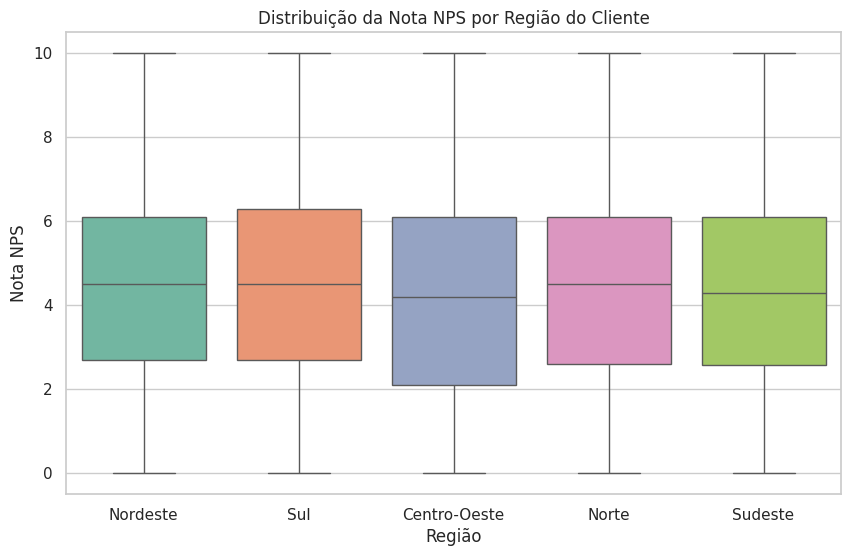

In [87]:
#região x nota
sns.boxplot(data=df, x='customer_region', y='nps_score', palette='Set2')
plt.title('Distribuição da Nota NPS por Região do Cliente')
plt.xlabel('Região')
plt.ylabel('Nota NPS')
plt.xticks(rotation=0) # Mantém os nomes das regiões retos
plt.show()

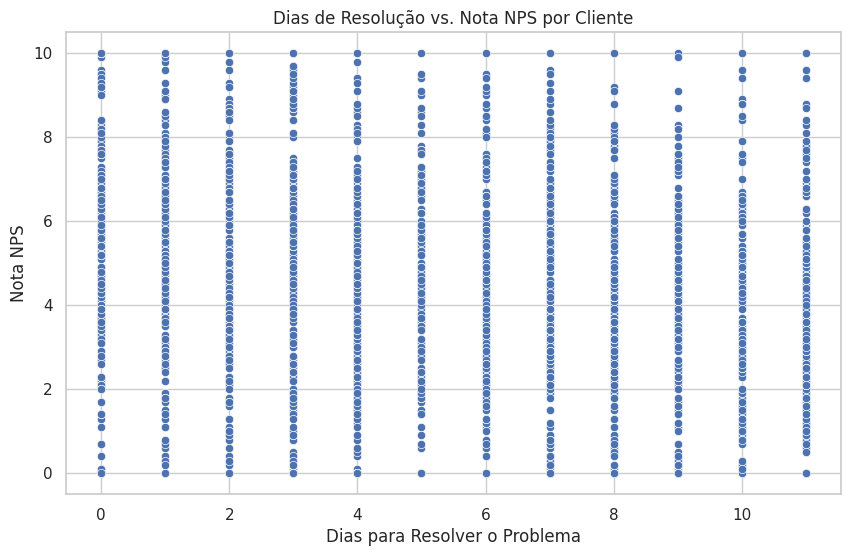

In [88]:
#tempo de resolução x nota
sns.scatterplot(data=df, x='resolution_time_days', y='nps_score')

plt.title('Dias de Resolução vs. Nota NPS por Cliente')
plt.xlabel('Dias para Resolver o Problema')
plt.ylabel('Nota NPS')

plt.show()

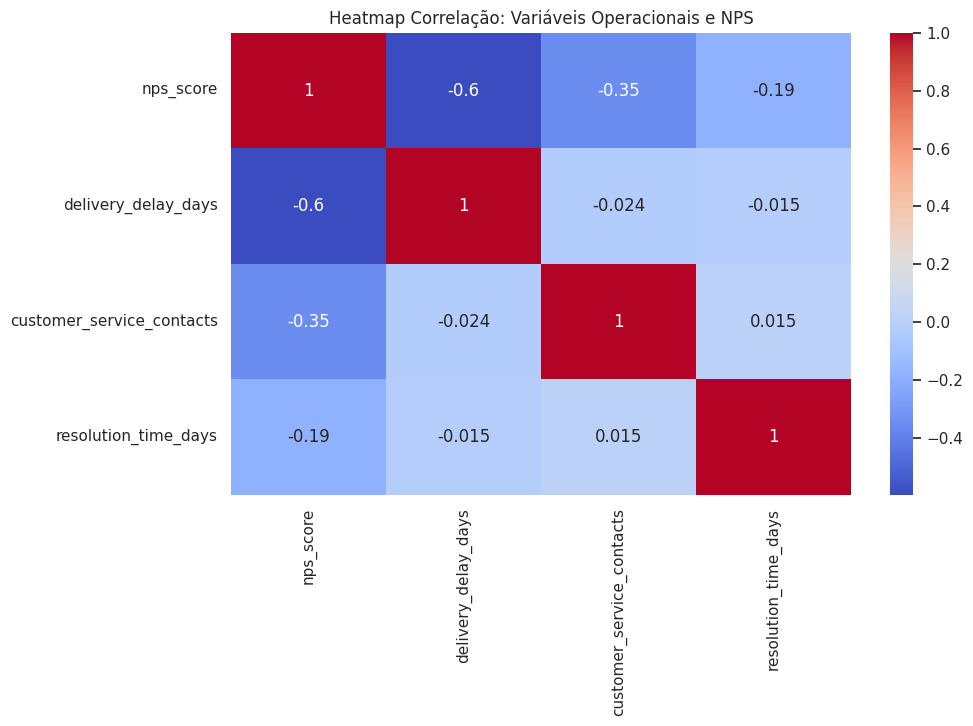

In [89]:
#Heatmap

#escolher algumas colunas pra facilitar a visualização
colunas_corr = ['nps_score', 'delivery_delay_days', 'customer_service_contacts', 'resolution_time_days']


sns.heatmap(df[colunas_corr].corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Correlação: Variáveis Operacionais e NPS')



plt.show()

## 3. Análise Exploratória dos Dados (EDA):Conclusões


* **Quais fatores parecem mais críticos para a satisfação? / O que mais gera detratores?**

  Os dados mostram claramente que o NPS da nossa empresa não depende de fatores demográficos ou comerciais.
  * O valor do pedido não influencia na nota (clientes que compram itens baratos ou caros reagem da mesma forma).
  * A região geográfica também é irrelevante (o comportamento de satisfação é homogêneo em todo o país).

  Portanto, o que gera detratores (notas de 0 a 6) são exclusivamente os atritos operacionais:
  1. Atrasos na entrega: O principal destruidor da experiência inicial.
  2. Esforço excessivo no suporte (SAC): Quando o cliente precisa entrar em contato múltiplas vezes e enfrenta um tempo de resolução prolongado.
<br>

* **Existe algum “ponto de ruptura” na experiência do cliente?**

  Sim. O ponto de ruptura ocorre quando a promessa de conveniência do e-commerce é quebrada por **falhas na execução**.
  * Na logística, qualquer dia de atraso além do prazo prometido despenca a nota do cliente.
  * No pós-venda, a tolerância do consumidor acaba se ele precisar abrir mais de um chamado para resolver o mesmo problema. O cliente não aceita pagar pelo produto e ainda ter que "trabalhar" para corrigir um erro da empresa.
<br>

* **Que tipo de cliente tende a ter NPS mais alto ou mais baixo?**

  * O perfil do Detrator (NPS Baixo): Não é definido por quanto ele gastou ou de onde ele é, mas sim pelo **nível de estresse na jornada. É o cliente que sofreu com atraso na entrega e teve que recorrer a um suporte demorado.
  * O perfil do Promotor (NPS Alto): É o cliente que teve uma experiência "invisível" — o produto chegou no prazo acordado e ele não precisou acionar o suporte nenhuma vez. No e-commerce, o melhor atendimento é aquele que o cliente não precisa usar.

## Análise de Correlação


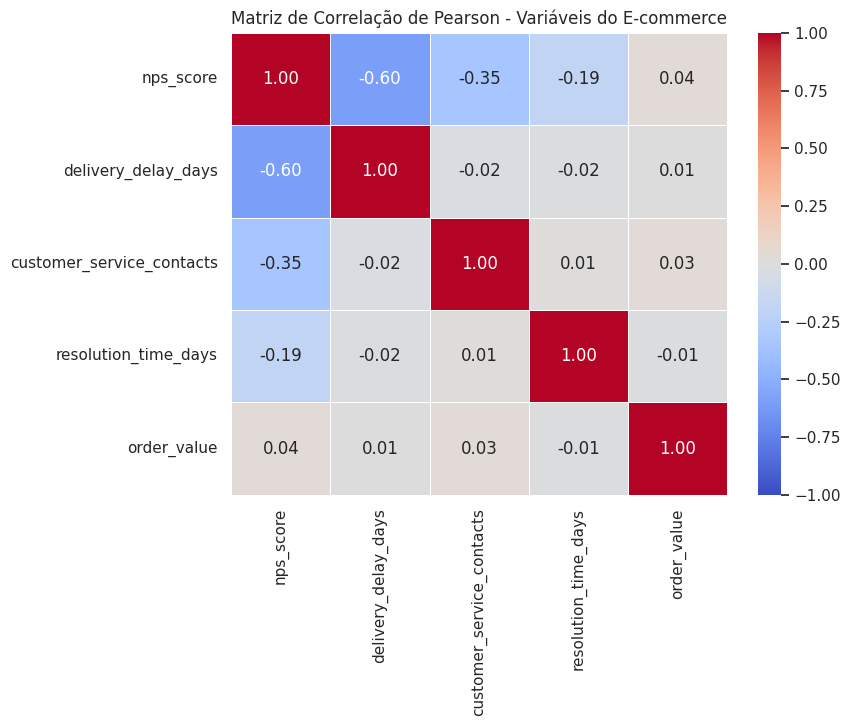

In [90]:
# Correlação de Pearson
#selecionando coluna numericas relevantes
colunas_numericas = ['nps_score', 'delivery_delay_days', 'customer_service_contacts', 'resolution_time_days', 'order_value']
df_correlacao = df[colunas_numericas]

# calculando matriz de correlação
matriz_corr = df_correlacao.corr(method='pearson')

# heatmap correlação
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação de Pearson - Variáveis do E-commerce')
plt.show()

In [91]:
#Correlação Spearman
corr_spearman = df_correlacao.corr(method='spearman')

print("=== MATRIZ DE CORRELAÇÃO DE SPEARMAN ===")
display(corr_spearman)

=== MATRIZ DE CORRELAÇÃO DE SPEARMAN ===


,nps_score,delivery_delay_days,customer_service_contacts,resolution_time_days,order_value
nps_score,1.000000,-0.586217,-0.336385,-0.190330,0.035891
delivery_delay_days,-0.586217,1.000000,-0.024184,-0.013963,0.017986
customer_service_contacts,-0.336385,-0.024184,1.000000,0.015807,0.014117
resolution_time_days,-0.190330,-0.013963,0.015807,1.000000,-0.009330
order_value,0.035891,0.017986,0.014117,-0.009330,1.000000


In [92]:
corr_kendall = df_correlacao.corr(method='kendall')

print("=== MATRIZ DE CORRELAÇÃO DE KENDALL ===")
display(corr_kendall)

=== MATRIZ DE CORRELAÇÃO DE KENDALL ===


,nps_score,delivery_delay_days,customer_service_contacts,resolution_time_days,order_value
nps_score,1.000000,-0.452108,-0.254505,-0.133478,0.023984
delivery_delay_days,-0.452108,1.000000,-0.019594,-0.010529,0.012872
customer_service_contacts,-0.254505,-0.019594,1.000000,0.012073,0.010357
resolution_time_days,-0.133478,-0.010529,0.012073,1.000000,-0.006245
order_value,0.023984,0.012872,0.010357,-0.006245,1.000000


## 4. Estratégia de Modelagem: Regressão vs. Classificação

  Ao pensarmos em antecipar a satisfação do cliente antes do disparo da pesquisa de NPS, podemos avaliar duas abordagens preditivas principais:
1. **Modelo de Classificação:** Agrupar os clientes em categorias binárias (ex.: satisfeitos vs. insatisfeitos). É útil para criar réguas de comunicação padronizadas, mas mascara a severidade real do atrito operacional (um cliente nota 6 acaba caindo no mesmo balde de um cliente nota 0).
2. **Modelo de Regressão:** Prever a nota de NPS de forma exata, em uma escala contínua.

  Como queremos extrair o peso exato de cada gargalo operacional (por exemplo, o impacto real de cada dia a mais de atraso), a **Regressão** se mostra a abordagem mais adequada.
<br>


* **A variável alvo (Target):** `nps_score` (escala contínua de 0 a 10).
* **Variáveis de entrada (Features):** Selecionadas com base na nossa Análise Exploratória (EDA) e Validação de Correlação, focando nos atritos operacionais: `delivery_delay_days`, `customer_service_contacts`, `resolution_time_days` e `order_value`.
* **Separação dos Dados:** Utilizaremos o padrão hold-out (`train_test_split`), separando 80% dos dados para treinar os algoritmos e 20% de dados inéditos para testes e validação.
* **Escolha do Modelo:** Construiremos dois cenários de regressão utilizando o método *Ordinary Least Squares* (OLS) via `statsmodels`: um **Modelo Simples** (focado exclusivamente na principal dor do cliente, o atraso logístico) e um **Modelo Múltiplo** (englobando os demais atritos da jornada operacional).
* **Avaliação dos Resultados:** Para validar qual abordagem reflete melhor a realidade do negócio, compararemos a performance de ambos os modelos nos dados de teste utilizando as métricas MAE (Erro Médio Absoluto), MSE (Erro Quadrático Médio) e RMSE (Raiz do Erro Quadrático).

Abaixo, iniciamos a implementação técnica com a separação da base de dados.

## Preparação e Separação dos dados

In [93]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# separando os dados: 80% treino e 20% teste
df_treino, df_teste = train_test_split(df, test_size=0.2, random_state=42)

# Definindo a variável alvo (Y) para ambos os modelos
Y_treino = df_treino['nps_score']
Y_teste = df_teste['nps_score']

print(f"Tamanho do conjunto de Treino: {X_treino.shape[0]} amostras")
print(f"Tamanho do conjunto de Teste: {X_teste.shape[0]} amostras")

Tamanho do conjunto de Treino: 2000 amostras
Tamanho do conjunto de Teste: 500 amostras


## Modelagem de Dados

In [94]:
#Regressão Linear Simples
#Objetivo: Testar a relação individual da variável mais crítica (delivery_delay_days) sobre a nota de NPS (nps_score).
# Variável explicativa: 'delivery_delay_days'

# Preparando a variável X para o treino e para o teste
X_treino_simples = sm.add_constant(df_treino[['delivery_delay_days']])
X_teste_simples = sm.add_constant(df_teste[['delivery_delay_days']])

# Ajustando o modelo com os dados de treino
modelo_simples = sm.OLS(Y_treino, X_treino_simples).fit()

# Exibindo o resumo
print("=== RESUMO: MODELO SIMPLES ===")
print(modelo_simples.summary())

=== RESUMO: MODELO SIMPLES ===
                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     1056.
Date:                Sun, 23 Aug 2026   Prob (F-statistic):          2.90e-186
Time:                        20:13:44   Log-Likelihood:                -4253.2
No. Observations:                2000   AIC:                             8510.
Df Residuals:                    1998   BIC:                             8522.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
con

In [95]:
#regressão linear múltipla
# objetivo: expandir modelo incluindo todas as variáveis operacionais preditoras para explicar o comportamento do NPS.
#Variáveis explicativas: Atraso, Contatos, Tempo de Resolução e Valor do Pedido

cols_multiplo = ['delivery_delay_days', 'customer_service_contacts', 'resolution_time_days', 'order_value']
# Preparando as variáveis X para o treino e para o teste
X_treino_multiplo = sm.add_constant(df_treino[cols_multiplo])
X_teste_multiplo = sm.add_constant(df_teste[cols_multiplo])

# Ajustando o modelo com os dados de treino
modelo_multiplo = sm.OLS(Y_treino, X_treino_multiplo).fit()

# exibindo o resumo
print("=== RESUMO: MODELO MÚLTIPLO ===")
print(modelo_multiplo.summary())

=== RESUMO: MODELO MÚLTIPLO ===
                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     560.5
Date:                Sun, 23 Aug 2026   Prob (F-statistic):          4.94e-324
Time:                        20:13:44   Log-Likelihood:                -3924.2
No. Observations:                2000   AIC:                             7858.
Df Residuals:                    1995   BIC:                             7886.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [96]:
#Avaliação de performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Previsões e métricas do Modelo de regressão simples
y_pred_simples = modelo_simples.predict(X_teste_simples)
mae_s = mean_absolute_error(Y_teste, y_pred_simples)
mse_s = mean_squared_error(Y_teste, y_pred_simples)
rmse_s = np.sqrt(mse_s)

# 2. Previsões e métricas do Modelo  de regressão Múltipla
y_pred_multiplo = modelo_multiplo.predict(X_teste_multiplo)
mae_m = mean_absolute_error(Y_teste, y_pred_multiplo)
mse_m = mean_squared_error(Y_teste, y_pred_multiplo)
rmse_m = np.sqrt(mse_m)

# 3. Comparativo dos resultados
print("=== PERFORMANCE NOS DADOS DE TESTE (20% DA BASE) ===")
print("\n[ MODELO SIMPLES (Apenas Atraso) ]")
print(f'MAE : {mae_s:.4f}')
print(f'MSE : {mse_s:.4f}')
print(f'RMSE: {rmse_s:.4f}')

print("\n[ MODELO MÚLTIPLO (Múltiplos Fatores) ]")
print(f'MAE : {mae_m:.4f}')
print(f'MSE : {mse_m:.4f}')
print(f'RMSE: {rmse_m:.4f}')

=== PERFORMANCE NOS DADOS DE TESTE (20% DA BASE) ===

[ MODELO SIMPLES (Apenas Atraso) ]
MAE : 1.5774
MSE : 3.7887
RMSE: 1.9465

[ MODELO MÚLTIPLO (Múltiplos Fatores) ]
MAE : 1.3675
MSE : 2.9291
RMSE: 1.7115


### Justificativa Técnica e Aplicação Prática no Negócio

* **A Escolha Final: Regressão Linear Múltipla**

  Como os resultados acima provam, a **Regressão Múltipla** apresentou métricas de erro menores (MAE e RMSE). Isso comprova que a insatisfação do cliente não nasce de uma única falha isolada, mas sim do acúmulo de atritos (atraso logístico somado ao esforço no SAC). Trazendo para a visão de negócio, prever a nota exata nos dá a precisão necessária para montar matrizes de priorização. A gestão consegue direcionar o orçamento de recuperação focando exatamente naqueles clientes com previsão de nota mais crítica, otimizando os custos operacionais.
<br>

* **Utilização na Prática pela Empresa**
  No dia a dia, a ideia é que esse modelo rode de forma integrada aos pipelines de dados da logística e do atendimento. Bateu no sistema que uma entrega estourou o SLA estipulado? O modelo já calcula na hora o risco de queda no NPS. Com isso, antes mesmo de a pesquisa oficial ser disparada, conseguimos gerar alertas automatizados para o time de Experiência do Cliente atuar de forma preventiva (ex.: acionar o cliente, estornar o frete ou aplicar um desconto em tempo real), revertendo o atrito de forma proativa.

In [100]:
#salvar os modelos para entrega no github
import os
import pickle

# Cria a pasta 'models' se ela não existir
os.makedirs('models', exist_ok=True)

# Salva o modelo treinado
with open('models/modelo_nps.pkl', 'wb') as f:
    pickle.dump(modelo_multiplo, f)

print("Modelo salvo com sucesso na pasta models!")

Modelo salvo com sucesso na pasta models!
